═══════════════════════════════════════════════════════════════════════════
📌 Notebook 5: Modelagem Final - KMeans + PCA
═══════════════════════════════════════════════════════════════════════════

Neste notebook vamos:
✅ Treinar o modelo KMeans com K ideal
✅ Aplicar PCA para redução de dimensionalidade
✅ Visualizar clusters em 2D e 3D
✅ Analisar centróides dos clusters
✅ Avaliar qualidade do clustering
✅ Atribuir clusters aos municípios
✅ Salvar modelo treinado

⏱️ Tempo estimado: 30-40 minutos

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Setup
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

import joblib
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("🤖 MODELAGEM FINAL - KMeans + PCA")
print("="*80)
print("✅ Bibliotecas carregadas!")
print()

🤖 MODELAGEM FINAL - KMeans + PCA
✅ Bibliotecas carregadas!



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados e configurações
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import pandas as pd

print("="*80)
print("📂 CARREGANDO DADOS E CONFIGURAÇÕES")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Paths
data_path = base_path / 'data/processed/municipios_preprocessed.csv'
features_path = base_path / 'outputs/results/features_selecionadas.json'
k_path = base_path / 'outputs/results/k_escolhido.json'

# Carregar dataset processado
df = pd.read_csv(data_path)
print(f"✅ Dataset carregado: {len(df):,} municípios")

# Carregar features selecionadas
with open(features_path, 'r', encoding='utf-8') as f:
    features_metadata = json.load(f)
    selected_features = features_metadata['features_selecionadas']

print(f"✅ Features carregadas: {len(selected_features)}")

# Carregar K ideal
with open(k_path, 'r', encoding='utf-8') as f:
    k_config = json.load(f)
    K_IDEAL = int(k_config['k_escolhido'])

print(f"✅ K ideal carregado: {K_IDEAL}")
print()

# Extrair matriz X
X = df[selected_features].values

print(f"📊 Matriz X: {X.shape[0]:,} municípios × {X.shape[1]} features")
print()
print("📋 Features utilizadas:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")
print()


📂 CARREGANDO DADOS E CONFIGURAÇÕES

✅ Dataset carregado: 5,204 municípios
✅ Features carregadas: 7
✅ K ideal carregado: 4

📊 Matriz X: 5,204 municípios × 7 features

📋 Features utilizadas:
   1. log_populacao
   2. log_densidade
   3. pib_per_capita
   4. taxa_alfabetizacao
   5. mortalidade_infantil
   6. esgoto_adequado
   7. saude_per_10k



In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: Treinar modelo KMeans final
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print(f"🎯 TREINANDO KMEANS FINAL COM K = {K_IDEAL}")
print("="*80)
print()

print("💡 PARÂMETROS DO KMEANS:")
print(f"   • n_clusters: {K_IDEAL}")
print(f"   • n_init: 50 (múltiplas inicializações para melhor resultado)")
print(f"   • max_iter: 500 (iterações máximas)")
print(f"   • random_state: {RANDOM_STATE} (reprodutibilidade)")
print(f"   • algorithm: lloyd (padrão, mais estável)")
print()

print("🔄 Treinando modelo...")
print("   (Isso pode levar alguns segundos...)")
print()

import time
start_time = time.time()

# Treinar KMeans com parâmetros otimizados
kmeans = KMeans(
    n_clusters=K_IDEAL,
    n_init=50,  # Mais inicializações = melhor resultado
    max_iter=500,
    random_state=RANDOM_STATE,
    algorithm='lloyd'
)

# Fit e predict
labels = kmeans.fit_predict(X)

training_time = time.time() - start_time

print(f"✅ Modelo treinado em {training_time:.2f} segundos!")
print()

# Calcular métricas finais
print("📊 MÉTRICAS DO MODELO FINAL:")
print()

inertia = kmeans.inertia_
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)
calinski = calinski_harabasz_score(X, labels)

print(f"   Inércia (WCSS): {inertia:,.2f}")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"   Calinski-Harabasz Score: {calinski:,.2f}")
print()

# Interpretar Silhouette
if silhouette > 0.7:
    quality = "EXCELENTE ✨"
    interpretation = "Clusters muito bem definidos e separados"
elif silhouette > 0.5:
    quality = "BOM ✅"
    interpretation = "Clusters bem definidos"
elif silhouette > 0.3:
    quality = "RAZOÁVEL ⚠️"
    interpretation = "Clusters com alguma sobreposição"
else:
    quality = "FRACO ❌"
    interpretation = "Clusters pouco definidos"

print(f"💎 QUALIDADE DO CLUSTERING: {quality}")
print(f"   {interpretation}")
print()

# Distribuição dos clusters
unique_labels, counts = np.unique(labels, return_counts=True)
print("📊 DISTRIBUIÇÃO DE MUNICÍPIOS POR CLUSTER:")
print()

cluster_dist = pd.DataFrame({
    'Cluster': unique_labels,
    'Municipios': counts,
    'Percentual': (counts / len(labels)) * 100
}).sort_values('Municipios', ascending=False)

for idx, row in cluster_dist.iterrows():
    bar = '█' * int(row['Percentual'] / 2)
    print(f"   Cluster {int(row['Cluster'])}: {int(row['Municipios']):5,} municípios ({row['Percentual']:5.1f}%) {bar}")

print()

🎯 TREINANDO KMEANS FINAL COM K = 4

💡 PARÂMETROS DO KMEANS:
   • n_clusters: 4
   • n_init: 50 (múltiplas inicializações para melhor resultado)
   • max_iter: 500 (iterações máximas)
   • random_state: 42 (reprodutibilidade)
   • algorithm: lloyd (padrão, mais estável)

🔄 Treinando modelo...
   (Isso pode levar alguns segundos...)

✅ Modelo treinado em 2.56 segundos!

📊 MÉTRICAS DO MODELO FINAL:

   Inércia (WCSS): 24,804.41
   Silhouette Score: 0.1513
   Davies-Bouldin Index: 1.7919
   Calinski-Harabasz Score: 812.26

💎 QUALIDADE DO CLUSTERING: FRACO ❌
   Clusters pouco definidos

📊 DISTRIBUIÇÃO DE MUNICÍPIOS POR CLUSTER:

   Cluster 0: 2,780 municípios ( 53.4%) ██████████████████████████
   Cluster 1: 1,220 municípios ( 23.4%) ███████████
   Cluster 2:   663 municípios ( 12.7%) ██████
   Cluster 3:   541 municípios ( 10.4%) █████



🎯 ANÁLISE DOS CENTRÓIDES

💡 O QUE SÃO CENTRÓIDES?

   Os centróides são os 'centros' de cada cluster.
   Representam o perfil médio dos municípios naquele grupo.

📊 CENTRÓIDES (VALORES NORMALIZADOS):



,Cluster,log_populacao,log_densidade,pib_per_capita,taxa_alfabetizacao,mortalidade_infantil,esgoto_adequado,saude_per_10k
0,0,-0.196285,-0.261537,-0.392618,-0.107358,0.088162,-0.145463,-0.209898
1,1,1.230372,1.149179,-0.014003,0.066965,-0.011517,0.090076,-0.606583
2,2,-1.200273,-0.571407,0.007015,-0.004647,0.069684,0.028977,2.029460
3,3,-0.295010,-0.547290,2.040499,0.406356,-0.512457,0.508842,-0.040639



🎨 VISUALIZAÇÃO DOS CENTRÓIDES:

✅ Gráfico salvo: ..\outputs\figures\14_centroides_heatmap.png


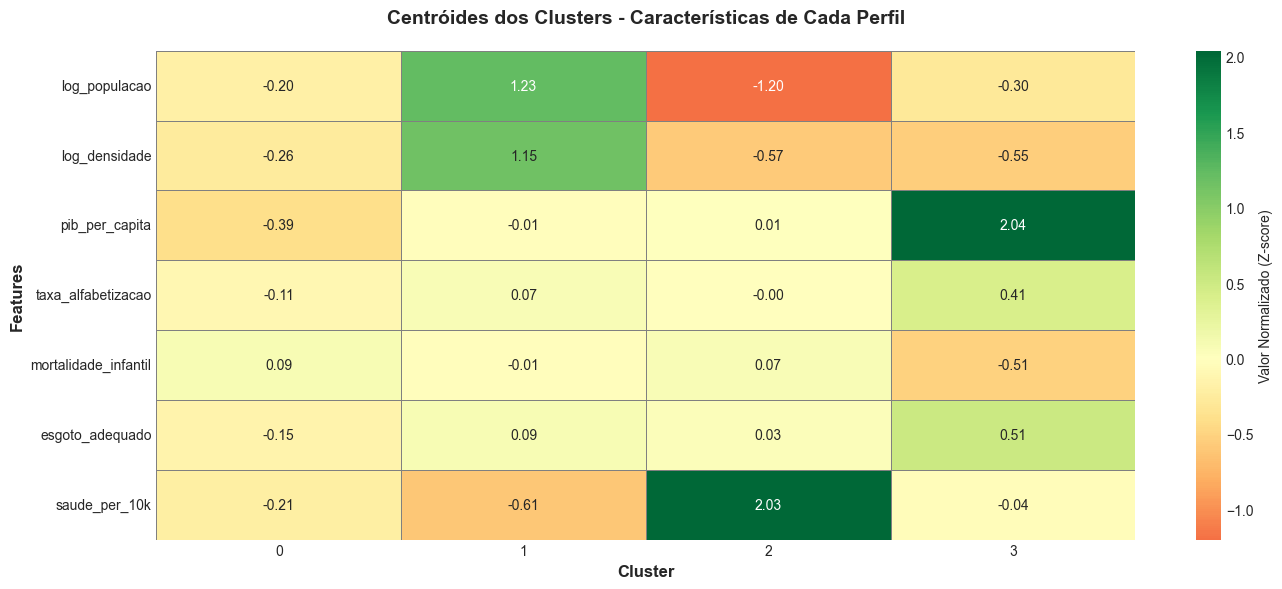


💡 INTERPRETAÇÃO DO HEATMAP:
   • Verde: Valor acima da média (positivo)
   • Vermelho: Valor abaixo da média (negativo)
   • Amarelo: Próximo da média (neutro)



In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: Análise dos centróides
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*80)
print("🎯 ANÁLISE DOS CENTRÓIDES")
print("="*80)
print()

print("💡 O QUE SÃO CENTRÓIDES?")
print()
print("   Os centróides são os 'centros' de cada cluster.")
print("   Representam o perfil médio dos municípios naquele grupo.")
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Criar DataFrame com centróides
centroids_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=selected_features
)
centroids_df.insert(0, 'Cluster', range(K_IDEAL))

print("📊 CENTRÓIDES (VALORES NORMALIZADOS):")
print()
display(centroids_df)

# Visualizar centróides como heatmap
print()
print("🎨 VISUALIZAÇÃO DOS CENTRÓIDES:")
print()

plt.figure(figsize=(14, K_IDEAL * 1.5))

# Preparar dados para heatmap (features nas linhas)
heatmap_data = centroids_df.set_index('Cluster').T

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Valor Normalizado (Z-score)'},
    linewidths=0.5,
    linecolor='gray'
)

plt.title(
    'Centróides dos Clusters - Características de Cada Perfil',
    fontsize=14,
    fontweight='bold',
    pad=20
)
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

plt.tight_layout()

# Salvar figura (caminho corrigido)
output_file = output_dir / '14_centroides_heatmap.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()

print()
print("💡 INTERPRETAÇÃO DO HEATMAP:")
print("   • Verde: Valor acima da média (positivo)")
print("   • Vermelho: Valor abaixo da média (negativo)")
print("   • Amarelo: Próximo da média (neutro)")
print()


🔬 PCA - ANÁLISE DE COMPONENTES PRINCIPAIS

💡 O QUE É PCA?

   PCA (Principal Component Analysis) é uma técnica de redução
   de dimensionalidade que transforma os dados em novos eixos
   (componentes principais) que capturam a máxima variância.

   OBJETIVO:
   • Reduzir de 7 dimensões (features) para 2-3 (visualização)
   • Manter o máximo de informação possível

   Como funciona:
   • PC1: Direção de maior variância nos dados
   • PC2: Segunda maior variância (perpendicular a PC1)
   • PC3: Terceira maior variância (perpendicular a PC1 e PC2)

🔄 Aplicando PCA...

📊 VARIÂNCIA EXPLICADA POR COMPONENTE:

   PC1: 27.66% | Acumulado: 27.66% ███████████████████████████
   PC2: 17.85% | Acumulado: 45.50% █████████████████
   PC3: 14.39% | Acumulado: 59.89% ██████████████
   PC4: 13.85% | Acumulado: 73.74% █████████████
   PC5: 11.08% | Acumulado: 84.82% ███████████
   PC6: 10.42% | Acumulado: 95.24% ██████████
   PC7:  4.76% | Acumulado: 100.00% ████

✅ Gráfico salvo: ..\outputs\figures\15_

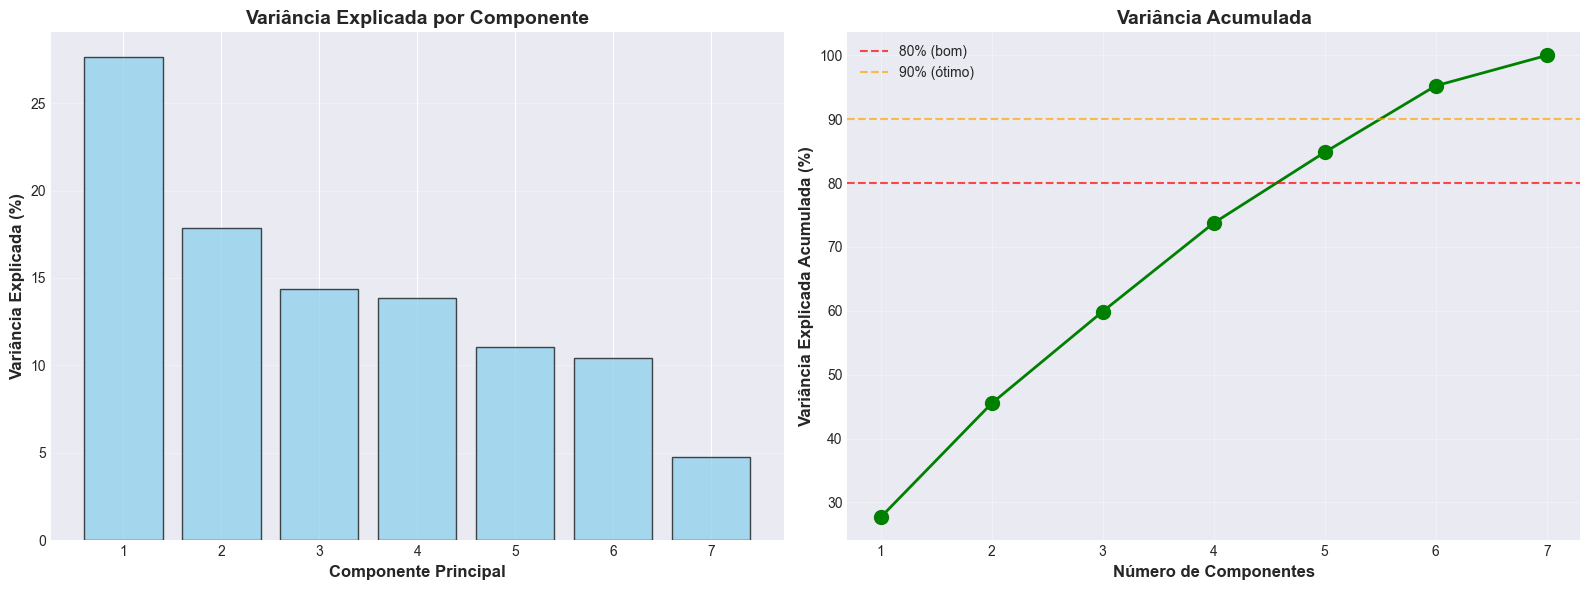


💡 ANÁLISE:
   • 2 componentes capturam: 45.5% da variância
   • 3 componentes capturam: 59.9% da variância

   ⚠️  45.5% é moderado, mas aceitável para visualização



In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 5: PCA - Preparação
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

print("="*80)
print("🔬 PCA - ANÁLISE DE COMPONENTES PRINCIPAIS")
print("="*80)
print()

print("💡 O QUE É PCA?")
print()
print("   PCA (Principal Component Analysis) é uma técnica de redução")
print("   de dimensionalidade que transforma os dados em novos eixos")
print("   (componentes principais) que capturam a máxima variância.")
print()
print("   OBJETIVO:")
print("   • Reduzir de 7 dimensões (features) para 2-3 (visualização)")
print("   • Manter o máximo de informação possível")
print()
print("   Como funciona:")
print("   • PC1: Direção de maior variância nos dados")
print("   • PC2: Segunda maior variância (perpendicular a PC1)")
print("   • PC3: Terceira maior variância (perpendicular a PC1 e PC2)")
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Aplicar PCA com diferentes números de componentes
print("🔄 Aplicando PCA...")
print()

# PCA completo (todos os componentes) para análise de variância
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

# Variância explicada por cada componente
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("📊 VARIÂNCIA EXPLICADA POR COMPONENTE:")
print()
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    bar = '█' * int(var * 100)
    print(f"   PC{i}: {var*100:5.2f}% | Acumulado: {cum_var*100:5.2f}% {bar}")

print()

# Visualizar variância explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Variância por componente
axes[0].bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)
axes[0].set_xlabel('Componente Principal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Variância Explicada (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Variância Explicada por Componente', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(1, len(explained_variance) + 1))

# Gráfico 2: Variância acumulada
axes[1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    'o-',
    color='green',
    linewidth=2,
    markersize=10
)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% (bom)')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% (ótimo)')
axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Variância Explicada Acumulada (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Variância Acumulada', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

plt.tight_layout()

# Salvar figura (caminho corrigido)
output_file = output_dir / '15_pca_variancia.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()

print()
print("💡 ANÁLISE:")
variance_2d = cumulative_variance[1] * 100
variance_3d = cumulative_variance[2] * 100 if len(cumulative_variance) > 2 else 0

print(f"   • 2 componentes capturam: {variance_2d:.1f}% da variância")
print(f"   • 3 componentes capturam: {variance_3d:.1f}% da variância")
print()

if variance_2d >= 70:
    print(f"   ✅ {variance_2d:.1f}% é suficiente para visualização 2D!")
else:
    print(f"   ⚠️  {variance_2d:.1f}% é moderado, mas aceitável para visualização")
print()


📊 VISUALIZAÇÃO 2D DOS CLUSTERS (PCA)

✅ PCA 2D aplicado!
   Variância explicada: 45.50%

🎨 Criando visualização interativa...

✅ Gráfico interativo salvo: ..\outputs\figures\16_clusters_pca_2d_interativo.html


✅ Gráfico estático salvo: ..\outputs\figures\17_clusters_pca_2d_estatico.png


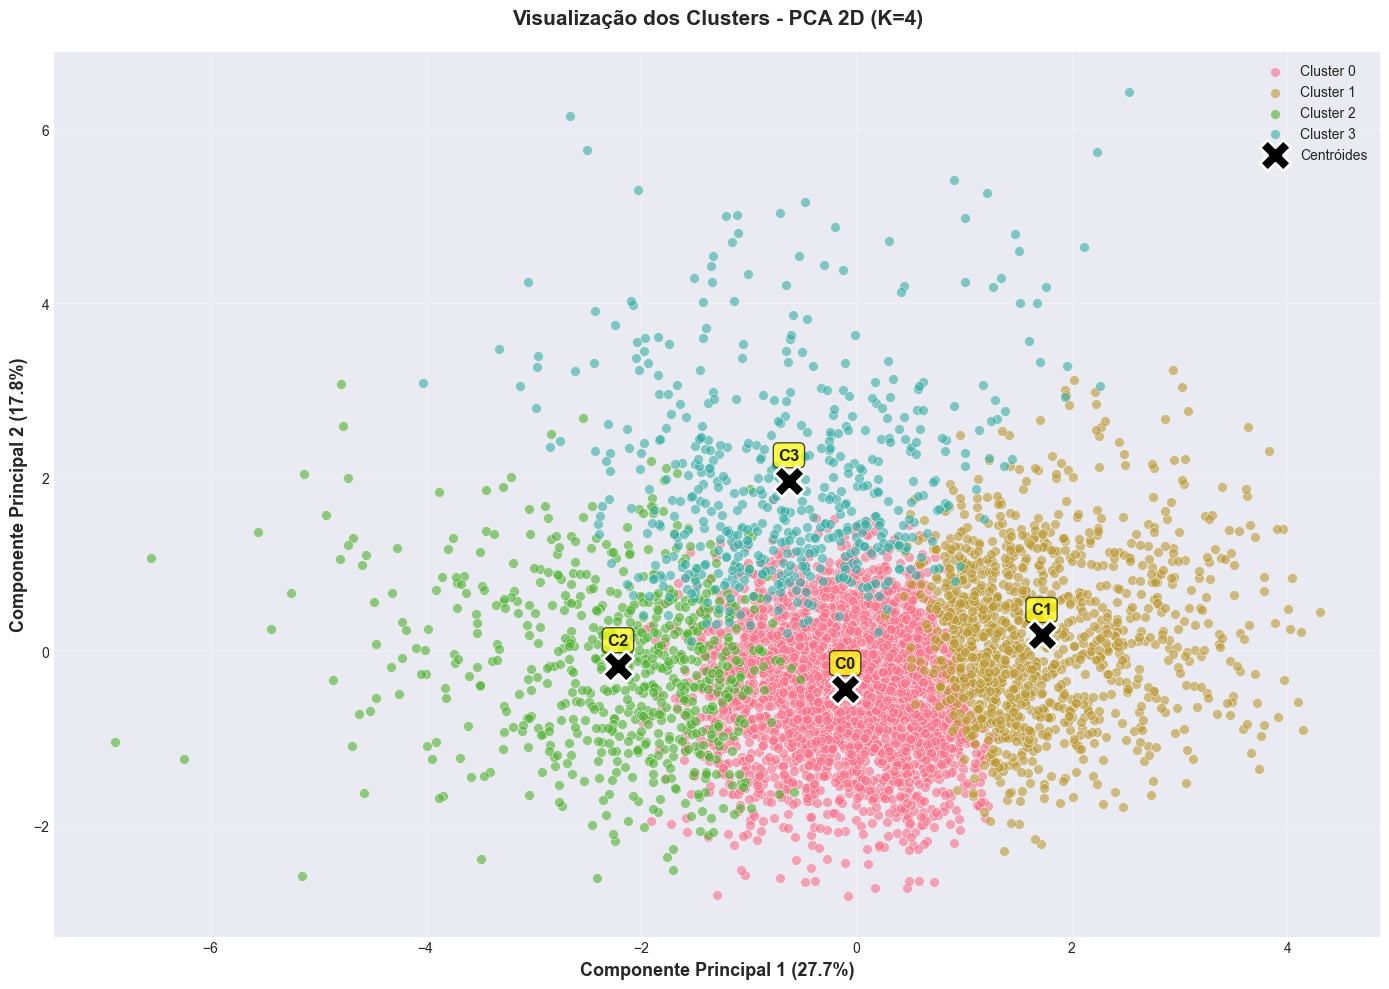

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: PCA 2D - Visualização
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("="*80)
print("📊 VISUALIZAÇÃO 2D DOS CLUSTERS (PCA)")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Aplicar PCA com 2 componentes
# -------------------------------------------------------------------------
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X)

print(f"✅ PCA 2D aplicado!")
print(f"   Variância explicada: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Criar DataFrame para visualização
df_viz = df.copy()
df_viz['PC1'] = X_pca_2d[:, 0]
df_viz['PC2'] = X_pca_2d[:, 1]
df_viz['Cluster'] = labels
df_viz['Cluster_Label'] = df_viz['Cluster'].apply(lambda x: f'Cluster {x}')

# -------------------------------------------------------------------------
# Plotly — Scatter interativo
# -------------------------------------------------------------------------
print("🎨 Criando visualização interativa...")
print()

fig = px.scatter(
    df_viz,
    x='PC1',
    y='PC2',
    color='Cluster_Label',
    hover_data=['nome_municipio', 'uf', 'regiao'],
    title=f'Clusters de Municípios Brasileiros - Visualização PCA 2D (K={K_IDEAL})',
    labels={
        'PC1': f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    height=700
)

# Adicionar centróides dos clusters
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)

fig.add_trace(go.Scatter(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    mode='markers+text',
    name='Centróides',
    marker=dict(
        size=20,
        color='black',
        symbol='x',
        line=dict(width=3, color='white')
    ),
    text=[f'C{i}' for i in range(K_IDEAL)],
    textposition='top center',
    textfont=dict(size=14, color='black', family='Arial Black'),
    hovertemplate='<b>Centróide Cluster %{text}</b><extra></extra>'
))

fig.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='white')))
fig.update_layout(
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255,255,255,0.8)"
    ),
    hovermode='closest'
)

output_html = output_dir / '16_clusters_pca_2d_interativo.html'
fig.write_html(output_html)
print(f"✅ Gráfico interativo salvo: {output_html}")
fig.show()

# -------------------------------------------------------------------------
# Matplotlib — Versão estática
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 10))

# Plot dos pontos
for cluster in range(K_IDEAL):
    cluster_points = X_pca_2d[labels == cluster]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

# Plot dos centróides
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=500,
    c='black',
    edgecolors='white',
    linewidth=2,
    label='Centróides',
    zorder=10
)

# Labels nos centróides
for i, (x, y) in enumerate(centroids_pca):
    plt.annotate(
        f'C{i}',
        xy=(x, y),
        xytext=(0, 15),
        textcoords='offset points',
        ha='center',
        fontsize=12,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
    )

plt.xlabel(
    f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)',
    fontsize=13, fontweight='bold'
)
plt.ylabel(
    f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)',
    fontsize=13, fontweight='bold'
)
plt.title(
    f'Visualização dos Clusters - PCA 2D (K={K_IDEAL})',
    fontsize=15,
    fontweight='bold',
    pad=20
)
plt.legend(loc='best', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_png = output_dir / '17_clusters_pca_2d_estatico.png'
plt.savefig(output_png, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico estático salvo: {output_png}")

plt.show()


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: PCA 3D - Visualização
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("🎨 VISUALIZAÇÃO 3D DOS CLUSTERS (PCA)")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Aplicar PCA com 3 componentes
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X)

print(f"✅ PCA 3D aplicado!")
print(f"   Variância explicada: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Adicionar ao DataFrame
df_viz['PC3'] = X_pca_3d[:, 2]

# Plotly 3D scatter
print("🎨 Criando visualização 3D interativa...")
print()

fig = px.scatter_3d(
    df_viz,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster_Label',
    hover_data=['nome_municipio', 'uf'],
    title=f'Clusters de Municípios Brasileiros - Visualização PCA 3D (K={K_IDEAL})',
    labels={
        'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    height=800
)

# Adicionar centróides 3D
centroids_pca_3d = pca_3d.transform(kmeans.cluster_centers_)

fig.add_trace(go.Scatter3d(
    x=centroids_pca_3d[:, 0],
    y=centroids_pca_3d[:, 1],
    z=centroids_pca_3d[:, 2],
    mode='markers+text',
    name='Centróides',
    marker=dict(
        size=15,
        color='black',
        symbol='diamond',
        line=dict(width=3, color='white')
    ),
    text=[f'C{i}' for i in range(K_IDEAL)],
    textposition='top center',
    textfont=dict(size=12, color='black'),
    hovertemplate='<b>Centróide Cluster %{text}</b><extra></extra>'
))

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.update_layout(
    template='plotly_white',
    scene=dict(
        xaxis_title=f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

output_html = output_dir / '18_clusters_pca_3d_interativo.html'
fig.write_html(output_html)
print(f"✅ Gráfico 3D interativo salvo: {output_html}")
fig.show()



🎨 VISUALIZAÇÃO 3D DOS CLUSTERS (PCA)

✅ PCA 3D aplicado!
   Variância explicada: 59.89%

🎨 Criando visualização 3D interativa...

✅ Gráfico 3D interativo salvo: ..\outputs\figures\18_clusters_pca_3d_interativo.html



📊 ANÁLISE DE SILHOUETTE POR CLUSTER

💡 O QUE É O SILHOUETTE PLOT?

   Mostra o quão bem cada município está agrupado.
   Cada barra representa um município.

   • Barras longas à direita: bem agrupado
   • Barras curtas: na fronteira entre clusters
   • Barras à esquerda: possivelmente no cluster errado

✅ Gráfico salvo: ..\outputs\figures\19_silhouette_plot.png


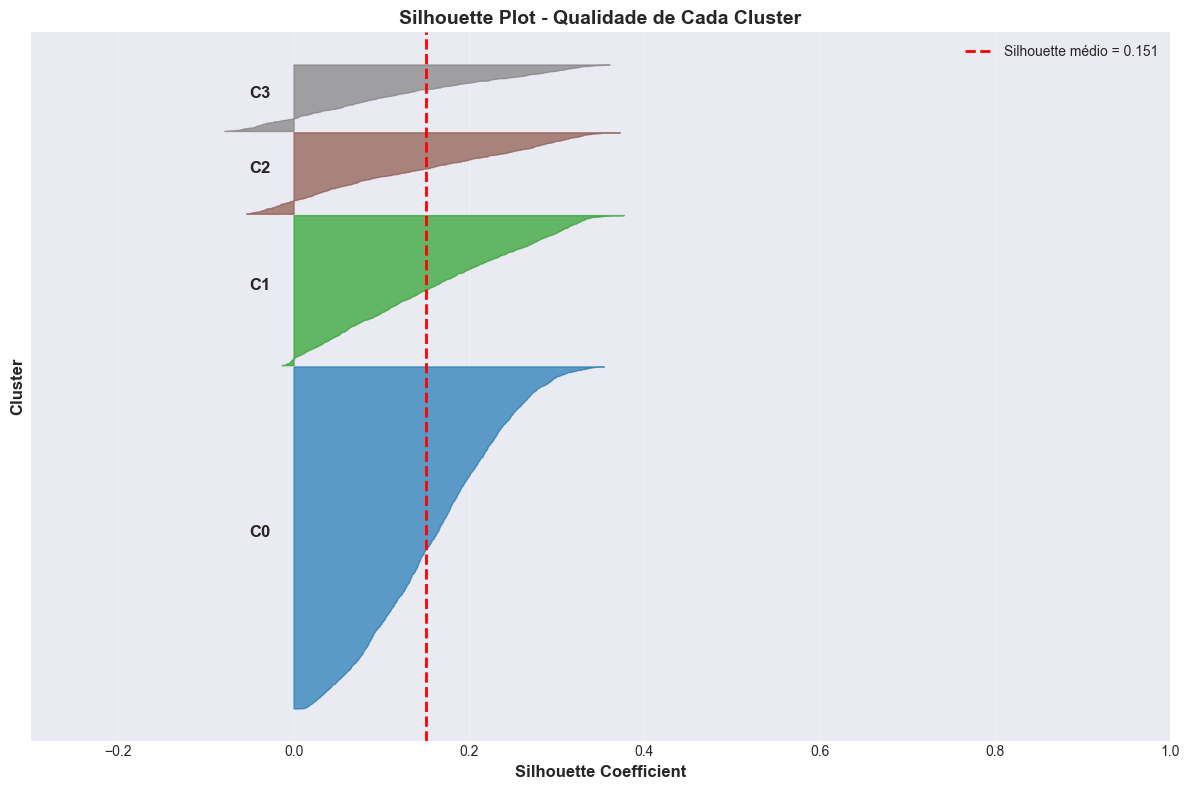


📊 SILHOUETTE SCORE POR CLUSTER:

   Cluster 0: 0.1605 (2,780 municípios) Fraco ████████
   Cluster 1: 0.1560 (1,220 municípios) Fraco ███████
   Cluster 2: 0.1335 (  663 municípios) Fraco ██████
   Cluster 3: 0.1160 (  541 municípios) Fraco █████



In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 8: Análise de Silhouette por cluster
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples

print("\n" + "="*80)
print("📊 ANÁLISE DE SILHOUETTE POR CLUSTER")
print("="*80)
print()

print("💡 O QUE É O SILHOUETTE PLOT?")
print()
print("   Mostra o quão bem cada município está agrupado.")
print("   Cada barra representa um município.")
print()
print("   • Barras longas à direita: bem agrupado")
print("   • Barras curtas: na fronteira entre clusters")
print("   • Barras à esquerda: possivelmente no cluster errado")
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Calcular silhouette por amostra
silhouette_vals = silhouette_samples(X, labels)

# Criar silhouette plot
fig, ax = plt.subplots(figsize=(12, 8))

y_lower = 10
colors = plt.cm.get_cmap('tab10')

for i in range(K_IDEAL):
    # Silhouettes do cluster i
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = colors(i / K_IDEAL)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )
    
    # Label do cluster
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        f'C{i}',
        fontsize=12,
        fontweight='bold'
    )
    
    y_lower = y_upper + 10

# Linha do silhouette médio
ax.axvline(
    x=silhouette,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Silhouette médio = {silhouette:.3f}'
)

ax.set_title(
    'Silhouette Plot - Qualidade de Cada Cluster',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Silhouette Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.set_yticks([])
ax.set_xlim([-0.3, 1])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

# Salvar figura (caminho corrigido)
output_file = output_dir / '19_silhouette_plot.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()

# -------------------------------------------------------------------------
# Silhouette médio por cluster
# -------------------------------------------------------------------------
print()
print("📊 SILHOUETTE SCORE POR CLUSTER:")
print()

for i in range(K_IDEAL):
    cluster_silhouette = silhouette_vals[labels == i].mean()
    n_samples = (labels == i).sum()
    
    if cluster_silhouette > 0.7:
        quality = "Excelente"
    elif cluster_silhouette > 0.5:
        quality = "Bom"
    elif cluster_silhouette > 0.3:
        quality = "Razoável"
    else:
        quality = "Fraco"
    
    bar = '█' * int(cluster_silhouette * 50)
    print(
        f"   Cluster {i}: {cluster_silhouette:.4f} "
        f"({n_samples:5,} municípios) {quality} {bar}"
    )

print()


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 9: Salvar modelo e resultados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

print("="*80)
print("💾 SALVANDO MODELO E RESULTADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretórios
results_dir = base_path / 'outputs/results'
processed_dir = base_path / 'data/processed'
results_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Função utilitária para JSON-safe (numpy -> python)
# -------------------------------------------------------------------------
def to_py(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_py(x) for x in obj]
    return obj

# -------------------------------------------------------------------------
# 1. Salvar modelo KMeans
# -------------------------------------------------------------------------
model_path = results_dir / 'kmeans_model.pkl'
joblib.dump(kmeans, model_path)
print(f"✅ Modelo KMeans salvo: {model_path}")

# -------------------------------------------------------------------------
# 2. Salvar modelos PCA
# -------------------------------------------------------------------------
pca_2d_path = results_dir / 'pca_2d_model.pkl'
joblib.dump(pca_2d, pca_2d_path)
print(f"✅ Modelo PCA 2D salvo: {pca_2d_path}")

pca_3d_path = results_dir / 'pca_3d_model.pkl'
joblib.dump(pca_3d, pca_3d_path)
print(f"✅ Modelo PCA 3D salvo: {pca_3d_path}")

# -------------------------------------------------------------------------
# 3. Salvar dataset com clusters atribuídos
# -------------------------------------------------------------------------
df_viz['cluster'] = labels
output_dataset_path = processed_dir / 'municipios_com_clusters.csv'
df_viz.to_csv(output_dataset_path, index=False, encoding='utf-8')
print(f"✅ Dataset com clusters salvo: {output_dataset_path}")

# -------------------------------------------------------------------------
# 4. Salvar centróides
# -------------------------------------------------------------------------
centroids_path = results_dir / 'centroides.csv'
centroids_df.to_csv(centroids_path, index=False)
print(f"✅ Centróides salvos: {centroids_path}")

# -------------------------------------------------------------------------
# 5. Salvar coordenadas PCA
# -------------------------------------------------------------------------
pca_coords = pd.DataFrame({
    'codigo_ibge': df_viz['codigo_ibge'],
    'nome_municipio': df_viz['nome_municipio'],
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'cluster': labels
})

pca_coords_path = results_dir / 'coordenadas_pca.csv'
pca_coords.to_csv(pca_coords_path, index=False)
print(f"✅ Coordenadas PCA salvas: {pca_coords_path}")

# -------------------------------------------------------------------------
# 6. Salvar metadados do modelo
# -------------------------------------------------------------------------
model_metadata = {
    'k_clusters': int(K_IDEAL),
    'n_municipios': int(len(df)),
    'n_features': int(len(selected_features)),
    'features': selected_features,
    'random_state': int(RANDOM_STATE),
    'metricas': {
        'inertia': float(inertia),
        'silhouette': float(silhouette),
        'davies_bouldin': float(davies_bouldin),
        'calinski_harabasz': float(calinski),
        'qualidade': str(quality)
    },
    'pca_2d_variance': float(pca_2d.explained_variance_ratio_.sum()),
    'pca_3d_variance': float(pca_3d.explained_variance_ratio_.sum()),
    'training_time_seconds': float(training_time),
    'data_treinamento': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_path = results_dir / 'model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(to_py(model_metadata), f, indent=2, ensure_ascii=False)

print(f"✅ Metadados salvos: {metadata_path}")

print()
print("="*80)
print("🎉 MODELAGEM CONCLUÍDA COM SUCESSO!")
print("="*80)
print()
print("📊 RESUMO:")
print(f"   ✅ Modelo KMeans treinado com K = {K_IDEAL}")
print(f"   ✅ Qualidade: {quality} (Silhouette = {silhouette:.4f})")
print(f"   ✅ {len(df):,} municípios clusterizados")
print(f"   ✅ PCA 2D explica {pca_2d.explained_variance_ratio_.sum()*100:.1f}% da variância")
print(f"   ✅ PCA 3D explica {pca_3d.explained_variance_ratio_.sum()*100:.1f}% da variância")
print()
print("👉 PRÓXIMO PASSO:")
print("   Abra o notebook: 06_analise_clusters.ipynb")
print()
print("="*80)


💾 SALVANDO MODELO E RESULTADOS

✅ Modelo KMeans salvo: ..\outputs\results\kmeans_model.pkl
✅ Modelo PCA 2D salvo: ..\outputs\results\pca_2d_model.pkl
✅ Modelo PCA 3D salvo: ..\outputs\results\pca_3d_model.pkl
✅ Dataset com clusters salvo: ..\data\processed\municipios_com_clusters.csv
✅ Centróides salvos: ..\outputs\results\centroides.csv
✅ Coordenadas PCA salvas: ..\outputs\results\coordenadas_pca.csv
✅ Metadados salvos: ..\outputs\results\model_metadata.json

🎉 MODELAGEM CONCLUÍDA COM SUCESSO!

📊 RESUMO:
   ✅ Modelo KMeans treinado com K = 4
   ✅ Qualidade: Fraco (Silhouette = 0.1513)
   ✅ 5,204 municípios clusterizados
   ✅ PCA 2D explica 45.5% da variância
   ✅ PCA 3D explica 59.9% da variância

👉 PRÓXIMO PASSO:
   Abra o notebook: 06_analise_clusters.ipynb

